# Contact-force parameter sweep — control-response analysis

Analysis of the position-controller push sweep (`data/param_sweep/*.npz`). Each
condition is one combination of the four independent variables; every condition
holds **5 envs** through force goals **1, 2, 5, 10, 15 N** (fresh grasp/reset
before each goal, 2 s hold), logging every physics substep.

**Independent variables (x-axes):** `solver_position_iteration_count`,
`max_depenetration_velocity`, `sim.dt`, `contact_offset`.
**Line per plot:** force-target magnitude.

**Per-trajectory control-response metrics** (one trajectory = 1 env × 1 force level):
- **Steady-state force error** `sse` — settled contact force minus target (N).
- **Residual penetration** — tip depth below the box surface at steady state (mm).
- **Rise time** — 10→90 % of steady-state force after first contact (ms).
- **Overshoot** — peak force after first contact vs steady state (%).
- **Force noise / oscillation** — steady-state force std (N) (`ptp` also stored).
- **Loading hysteresis** — dynamic *F*–δ loop area (proxy; see note below).
- **Estimator cross-check** — steady-state (`pinv(J^T)·τ` − contact) and
  (dyn-consistent − contact) (N).

Metrics are computed per trajectory, then **aggregated by condition to mean ± std**
(the std band on each plot marginalizes the 3 other IVs and the 5 envs).

> **Failure modes the sweep exposes** — some corners don't hold contact:
> under-resolved contact (few iterations / coarse `dt`) **tunnels** into the box
> (contact sensor → 0 while the torque estimate stays high), and unstable corners
> **eject** the cylinder. These are flagged by `contact_established`; set
> `USE_ESTABLISHED_ONLY = True` in the globals cell to drop them from the plots.

> **Hysteresis caveat** — the protocol loads to a fixed setpoint with no explicit
> unload ramp, so true quasi-static load/unload hysteresis isn't measured. The
> `hysteresis` metric is the enclosed area of the *F*–δ trajectory (the dynamic
> overshoot/settle loop) — a proxy. Add a ramp-down phase to the sweep for the
> real thing.

In [45]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Global variables

In [46]:
# ---- dataset switch: flip between the cylinder/box and the FORGE peg/hole sweep ----
# "param_sweep" -> cylinder/box (Isaac-ContactForceTest); "param_sweep_forge" -> FORGE peg/hole.
DATASET = "param_sweep"

# ---- paths (relative to this notebook in data_analysis/) ----
DATA_DIR = f"../data/{DATASET}"                  # sweep .npz files
DF_PATH  = f"../data/{DATASET}_metrics.pkl"      # cached per-trajectory metrics (one per dataset)
REAL_GLOB = "../data/contact_force_real_*.npz"   # real-robot data (latest match is loaded)

# ---- metric-extraction constants ----
TIP_GAP = 2e-4              # m; spawn gap above surface (must match cfg.task.tip_gap)
TAIL_SECONDS = 0.5          # settled window (s) for steady-state metrics
CONTACT_THRESH_N = 0.05     # N; |Fz| above this counts as "in contact"
RISE_LO, RISE_HI = 0.1, 0.9 # rise-time fractions of steady-state force
FORCE_FIELD = "contact_force_ee"   # primary force signal (contact sensor, EE frame, +=press)
SIM_EMA_ALPHA = 0.25   # FORGE ft_smoothing_factor: EMA applied to the force per physics
                       # substep (what a FORGE-trained policy sees). Real robot uses 0.08.

# ---- independent variables (x-axes) + force target (one line per value) ----
IV_COLS = ["solver_iters", "max_depen", "sim_dt", "contact_offset"]
IV_LABELS = {"solver_iters": "solver_position_iteration_count",
             "max_depen": "max_depenetration_velocity (m/s)",
             "sim_dt": "physics rate 1/sim.dt (Hz)", "contact_offset": "contact_offset (m)"}
FORCE_COL = "force_target"

# ---- outcome-regime classifier (tunable; reclassify without rebuilding) ----
GAIN = 565.0             # z task gain used for the setpoint (cfg default_task_prop_gains[2])
V_SETTLE = 0.02          # m/s; tail settling speed below this = "settled"
PEN_TUNNEL = 0.5         # pen_ratio above this = tunneled (tip sank toward setpoint)
PEN_EJECT = -0.5         # pen_ratio below this = ejected -> unstable
PEN_RUNAWAY = 2.0        # pen_ratio above this = blew through the box -> unstable
REGIMES = ["good", "tunneling", "unstable"]
REGIME_COLORS = {"good": "#2ca02c", "tunneling": "#ff7f0e", "unstable": "#d62728"}

# Set True to keep only "good" (established) trajectories in the metric plots.
USE_ESTABLISHED_ONLY = False

# ---- global data filters: restrict which conditions feed EVERY plot ----
# Inclusive (min, max); None = unbounded. Edit here, then re-run the load cell.
# sim.dt is filtered by PHYSICS RATE in Hz (matches the axis): RATE_HZ_RANGE = (120, None)
# drops all 60 Hz data from every plot / aggregate.
SOLVER_ITERS_RANGE   = (None, None)   # solver_position_iteration_count
MAX_DEPEN_RANGE      = (None, None)   # max_depenetration_velocity (m/s)
RATE_HZ_RANGE        = (120, None)   # physics rate = 1/sim.dt (Hz)
CONTACT_OFFSET_RANGE = (None, None)   # contact_offset (m)
FORCE_TARGET_RANGE   = (None, None)   # force target (N)

# ---- figure export: every plotting cell also writes an .svg here, overwritten each run ----
FIG_DIR = "param_sweep_figs"
os.makedirs(FIG_DIR, exist_ok=True)

## Data loading & metric extraction

One row per trajectory (`condition × force level × env`). `np.load` is lazy, so
only the fields we touch are read — the large `mass_matrix`/`jacobian` arrays are
skipped. Metric identities are keyed off each file's authoritative `meta_*`
fields, not the filename.

In [47]:
def _first_cross(t, y, level):
    # time of first upward crossing of `level`; nan if never reached
    idx = int(np.argmax(y >= level))
    return float(t[idx]) if y[idx] >= level else np.nan


def _ema(x, alpha):
    # recursive EMA y[i] = alpha*x[i] + (1-alpha)*y[i-1], y[0]=x[0] (matches the
    # FORGE env's per-substep ft smoothing; adjust=False reproduces the recursion)
    return pd.Series(x).ewm(alpha=alpha, adjust=False).mean().to_numpy()


def traj_metrics(t, fz, pinv, dyn, eez, velz, target):
    # all control-response metrics for one trajectory (1 env, 1 force level)
    tail = t >= (t[-1] - TAIL_SECONDS)
    ss = float(fz[tail].mean())
    # FORGE-env-filtered contact (EMA per substep): what a trained policy would see
    fz_filt = _ema(fz, SIM_EMA_ALPHA)
    filt_contact_ss = float(fz_filt[tail].mean())
    filt_noise_std = float(fz_filt[tail].std())
    tail_speed = float(np.sqrt(np.mean(velz[tail] ** 2)))  # settling speed (m/s); ~0 = settled
    # penetration(t): tip descent below the box surface (m, + = penetrated)
    pen = (eez[0] - eez) - TIP_GAP
    resid_pen = float(pen[tail].mean())
    sse = ss - target
    noise_std = float(fz[tail].std())
    ptp = float(fz[tail].max() - fz[tail].min())
    # rise time / overshoot after first contact
    ci = int(np.argmax(np.abs(fz) >= CONTACT_THRESH_N))
    if (np.abs(fz[ci]) >= CONTACT_THRESH_N) and ss > 1e-6:
        t_lo = _first_cross(t[ci:], fz[ci:], RISE_LO * ss)
        t_hi = _first_cross(t[ci:], fz[ci:], RISE_HI * ss)
        rise_time = (t_hi - t_lo) if (np.isfinite(t_lo) and np.isfinite(t_hi)) else np.nan
        peak = float(fz[ci:].max())
        overshoot = (peak - ss) / ss * 100.0
        first_contact_t = float(t[ci])
    else:
        rise_time = overshoot = peak = first_contact_t = np.nan
    # dynamic F-delta loop area (overshoot hysteresis proxy; shoelace)
    hyst = float(0.5 * abs(np.sum(pen[:-1] * fz[1:] - pen[1:] * fz[:-1])))
    pinv_ss = float(pinv[tail].mean())
    dyn_ss = float(dyn[tail].mean())
    # per-step estimator-vs-contact over the WHOLE trajectory (RMS), not just the tail
    est_rmse_pinv = float(np.sqrt(np.mean((pinv - fz) ** 2)))
    est_rmse_dyn = float(np.sqrt(np.mean((dyn - fz) ** 2)))
    # settled-state oscillation of each estimator signal (cf. noise_std = contact sensor)
    dyn_noise_std = float(dyn[tail].std())
    pinv_noise_std = float(pinv[tail].std())
    return dict(steady_state_force=ss, sse=sse, abs_sse=abs(sse),
                residual_penetration=resid_pen, tail_speed=tail_speed,
                noise_std=noise_std, ptp=ptp,
                filt_contact_ss=filt_contact_ss, filt_noise_std=filt_noise_std,
                dyn_noise_std=dyn_noise_std, pinv_noise_std=pinv_noise_std,
                rise_time=rise_time, overshoot=overshoot, peak_force=peak,
                first_contact_t=first_contact_t, hysteresis=hyst,
                contact_ss=ss, pinv_ss=pinv_ss, dyn_ss=dyn_ss,
                est_err_pinv=pinv_ss - ss, est_err_dyn=dyn_ss - ss,
                est_rmse_pinv=est_rmse_pinv, est_rmse_dyn=est_rmse_dyn)


def build_dataframe(files):
    rows = []
    for f in files:
        d = np.load(f, allow_pickle=True)   # lazy: only accessed keys are read
        iv = dict(solver_iters=int(d["meta_solver_iters"]),
                  max_depen=float(d["meta_max_depenetration_velocity"]),
                  sim_dt=float(d["meta_sim_dt"]),
                  dt_denom=int(d["meta_dt_denom"]),
                  contact_offset=float(d["meta_contact_offset"]))
        ft = d["force_targets"]
        t_all = d["t"]
        fz_all = d[FORCE_FIELD][..., 2]
        pv_all = d["est_force_ee_pinv"][..., 2]
        dy_all = d["est_force_ee_dynconsistent"][..., 2]
        ez_all = d["ee_pos"][..., 2]
        vz_all = d["ee_linvel"][..., 2]
        nf, T, N = fz_all.shape
        for fi in range(nf):
            for ei in range(N):
                m = traj_metrics(t_all[fi], fz_all[fi, :, ei], pv_all[fi, :, ei],
                                 dy_all[fi, :, ei], ez_all[fi, :, ei], vz_all[fi, :, ei], float(ft[fi]))
                rows.append({**iv, FORCE_COL: float(ft[fi]), "env": ei, **m})
    return pd.DataFrame(rows)

In [48]:
# Load the cached DataFrame if present, else build it from the .npz files and cache it.
if os.path.exists(DF_PATH):
    df = pd.read_pickle(DF_PATH)
    print(f"loaded cached metrics: {DF_PATH}  ({len(df)} rows)")
else:
    files = sorted(glob.glob(os.path.join(DATA_DIR, "*.npz")))
    print(f"building metrics from {len(files)} npz files ...")
    df = build_dataframe(files)
    df.to_pickle(DF_PATH)
    print(f"saved {DF_PATH}  ({len(df)} rows)")

# Rebuild if the cache predates the newest features (tail_speed, per-step RMS, estimator std).
if "filt_noise_std" not in df.columns:
    print("cached metrics are stale; rebuilding from npz ...")
    df = build_dataframe(sorted(glob.glob(os.path.join(DATA_DIR, "*.npz"))))
    df.to_pickle(DF_PATH)

# Derived outcome classification -- edit the thresholds in the globals cell and
# re-run THIS cell to reclassify (no rebuild needed).
df["pen_ratio"] = df["residual_penetration"] / (df[FORCE_COL] / GAIN)

def classify_regime(pr, ts):
    if not (np.isfinite(pr) and np.isfinite(ts)):
        return "unstable"
    if pr < PEN_EJECT or pr > PEN_RUNAWAY:      # ejected up / blew through the box
        return "unstable"
    if ts > V_SETTLE and pr <= PEN_TUNNEL:      # never settled near the surface
        return "unstable"
    if pr > PEN_TUNNEL:                          # sank toward the setpoint (contact failed)
        return "tunneling"
    return "good"

df["regime"] = [classify_regime(pr, ts) for pr, ts in zip(df["pen_ratio"], df["tail_speed"])]
df["contact_established"] = df["regime"] == "good"   # "good" drives USE_ESTABLISHED_ONLY
print("overall regime %:", (df["regime"].value_counts(normalize=True) * 100).round(1).to_dict())

# ---- apply the global data filters (from the globals cell) to EVERY plot ----
def _in_range(series, rng):
    lo, hi = rng
    keep = pd.Series(True, index=series.index)
    if lo is not None: keep &= series >= lo
    if hi is not None: keep &= series <= hi
    return keep

df_full = df                                   # unfiltered frame, kept for reference
rate_hz = (1.0 / df["sim_dt"]).round()
_keep = (_in_range(df["solver_iters"], SOLVER_ITERS_RANGE)
         & _in_range(df["max_depen"], MAX_DEPEN_RANGE)
         & _in_range(rate_hz, RATE_HZ_RANGE)
         & _in_range(df["contact_offset"], CONTACT_OFFSET_RANGE)
         & _in_range(df[FORCE_COL], FORCE_TARGET_RANGE))
df = df[_keep].copy()
print(f"after global filters: kept {len(df)} / {len(df_full)} rows")
df.head()

loaded cached metrics: ../data/param_sweep_metrics.pkl  (14000 rows)
overall regime %: {'good': 64.0, 'unstable': 19.0, 'tunneling': 17.1}
after global filters: kept 10500 / 14000 rows


,solver_iters,max_depen,sim_dt,dt_denom,contact_offset,force_target,env,steady_state_force,sse,abs_sse,...,contact_ss,pinv_ss,dyn_ss,est_err_pinv,est_err_dyn,est_rmse_pinv,est_rmse_dyn,pen_ratio,regime,contact_established
0,128,0.1,0.008333,120,0.002,1.0,0,0.954435,-0.045565,0.045565,...,0.954435,0.955522,0.956685,0.001087,0.002250,0.744937,0.722768,0.276482,good,True
1,128,0.1,0.008333,120,0.002,1.0,1,0.994709,-0.005291,0.005291,...,0.994709,0.994614,0.995528,-0.000094,0.000819,0.756578,0.734398,0.257718,good,True
2,128,0.1,0.008333,120,0.002,1.0,2,0.934573,-0.065427,0.065427,...,0.934573,0.933907,0.935138,-0.000666,0.000565,0.897584,0.879771,0.304892,good,True
3,128,0.1,0.008333,120,0.002,1.0,3,1.000849,0.000849,0.000849,...,1.000849,1.000372,1.001477,-0.000476,0.000628,0.730725,0.707852,0.256369,good,True
4,128,0.1,0.008333,120,0.002,1.0,4,0.999229,-0.000771,0.000771,...,0.999229,0.995651,0.996760,-0.003578,-0.002469,0.731808,0.708857,0.255497,good,True


## Real-robot data (FR3)

Loads the latest `contact_force_real_*.npz` (2 force levels x 10 reps x 30 steps @
15 Hz). **The sim-vs-real plots use only `O_F_ext`** — the FR3's own external-wrench
estimate, the real analog of the sim contact sensor:

- **`ft_ee` = the FR3 `O_F_ext_hat_K`** — libfranka's external-wrench *estimate*:
  the measured `tau_J` with the full dynamic model (gravity + Coriolis + inertial +
  friction) removed by a momentum observer, then filtered. **The FR3 has NO physical
  F/T sensor.** Because Franka compensates gravity/dynamics/friction, it reads a
  clean ~4-9 N. Contact force = `-ft_ee_z` (sign-flipped vs the sim's +=pressing);
  no gravity hack needed.

**Not used**: `est_force_ee_pinv/dyn` (our `pinv(J^T).tau` / `Jbar^T.tau` maps of the
*raw* `tau_J`). On hardware the raw torque carries gravity + joint friction that we
can't cleanly remove without the model Franka uses internally — and `O_F_ext`
already does that compensation. The goal of this project is to make the **sim** match
`O_F_ext`, so it is the only real signal we load.

`REAL[force]` holds per-rep settled (last 0.5 s) values; `REAL_TRACES` holds
per-step traces for the time overlays. All sim-vs-real plots use **only the force
levels present in the real data**.

In [49]:
real_files = sorted(glob.glob(REAL_GLOB))
REAL, REAL_FORCES, REAL_TRACES = {}, [], {}
if real_files:
    rd = np.load(real_files[-1], allow_pickle=True)
    S = int(rd["settle_steps"])                     # settled window = last S steps (~0.5 s)
    # O_F_ext, negated to +pressing; Franka already gravity/dynamics-compensates it,
    # so this is the real signal we use (est_force_ee_pinv/dyn are ignored).
    contact = -rd["ft_ee"][..., 2]                  # (F,R,T)
    REAL_FORCES = [float(f) for f in rd["force_targets"]]
    rate = float(rd["control_rate_hz"])
    for fi, f in enumerate(REAL_FORCES):
        REAL[f] = dict(contact=contact[fi, :, -S:].mean(-1),     # (reps,) settled mean per rep
                       contact_std=contact[fi, :, -S:].std(-1))  # (reps,) within-rep settled std
        REAL_TRACES[f] = dict(t=np.arange(contact.shape[2]) / rate, contact=contact[fi])
    print(f"loaded real data: {os.path.basename(real_files[-1])}  forces={REAL_FORCES}")
    for f in REAL_FORCES:
        c = REAL[f]["contact"]
        print(f"  {f:g} N settled O_F_ext (mean+/-std over reps): {c.mean():+.2f} +/- {c.std():.2f}")
else:
    print("no real-robot data found (REAL_GLOB); sim-vs-real cells will no-op")

loaded real data: contact_force_real_20260715_134703.npz  forces=[1.0, 2.0]
  1 N settled O_F_ext (mean+/-std over reps): +4.02 +/- 0.52
  2 N settled O_F_ext (mean+/-std over reps): +9.15 +/- 0.09


## Processing — aggregation & plot helper

`plot_metric_vs_ivs` builds the standard figure for a metric: a 2×2 grid with the
metric on **y** and each independent variable on **x**, one **line per force
target**. For each x value it aggregates (mean ± std) across the other three IVs
and the 5 envs. There are 4 IVs → 4 subplots; force target is the line, not an
axis.

In [50]:
def _iv_order(iv, vals):
    # sim.dt is plotted as ascending physics rate (Hz) => descending dt (60 -> 480)
    return sorted(set(vals), reverse=(iv == "sim_dt"))


def _xticklabels(iv, vals):
    if iv == "sim_dt":
        return [f"{round(1/v)}" for v in vals]   # physics rate in Hz (1/dt)
    return [f"{v:g}" for v in vals]


def _slug(s):
    out = "".join(ch if ch.isalnum() else "_" for ch in str(s).lower())
    while "__" in out:
        out = out.replace("__", "_")
    return out.strip("_")


def save_fig(fig, name):
    # write every figure to FIG_DIR as .svg (overwritten each run)
    fig.savefig(os.path.join(FIG_DIR, _slug(name) + ".svg"), bbox_inches="tight")


def plot_metric_vs_ivs(metric, scale=1.0, ylabel=None, logy=False, title=None, mask="auto"):
    # 2x2 grid: `metric` (y) vs each IV (x); one line per force target.
    # mean +/- std aggregated over the 3 other IVs and the 5 envs.
    if isinstance(mask, str) and mask == "auto":
        mask = df["contact_established"] if USE_ESTABLISHED_ONLY else None
    data = df if mask is None else df[mask]
    forces = sorted(data[FORCE_COL].unique())
    cmap = plt.cm.viridis(np.linspace(0, 0.9, len(forces)))
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, iv in zip(axes.ravel(), IV_COLS):
        xs = _iv_order(iv, data[iv].unique())
        xpos = np.arange(len(xs))
        for c, ft in zip(cmap, forces):
            sub = data[data[FORCE_COL] == ft]
            g = sub.groupby(iv)[metric].agg(["mean", "std"]).reindex(xs)
            mean = g["mean"].values * scale
            std = np.nan_to_num(g["std"].values) * scale
            ax.plot(xpos, mean, "-o", color=c, ms=4, label=f"{ft:g} N")
            ax.fill_between(xpos, mean - std, mean + std, color=c, alpha=0.15)
        ax.set_xticks(xpos); ax.set_xticklabels(_xticklabels(iv, xs))
        ax.set_xlabel(IV_LABELS[iv]); ax.grid(alpha=0.3)
        if logy: ax.set_yscale("log")
        if ylabel: ax.set_ylabel(ylabel)
    axes[0, 0].legend(title="force target", fontsize=8)
    fig.suptitle(title or metric, fontweight="bold")
    fig.tight_layout()
    save_fig(fig, title or metric)
    return fig

## Outcome regimes — good / tunneling / unstable

Every trajectory is classified into one of three outcomes from its **penetration
ratio** (`residual_penetration / (force_target/gain)`) and its **tail settling
speed**:

- **good** — settled with the tip near the surface (`pen_ratio` in [-0.5, 0.5]).
- **tunneling** — contact failed to resist and the tip sank toward the commanded
  depth (`pen_ratio > 0.5`).
- **unstable** — ejected (`pen_ratio < -0.5`), blew through the box
  (`pen_ratio > 2`), or never settled near the surface (tail speed > 0.02 m/s
  while shallow).

Thresholds live in the globals cell. The stacked bars show the outcome mix for
each independent variable (aggregated over the other 3 IVs, force targets, and
envs). Key reads: instability lives almost entirely at `sim.dt = 1/60`; tunneling
is driven by too few solver iterations; `contact_offset` barely matters.

Overall outcome mix (%):
regime
good         85.3
tunneling    14.7


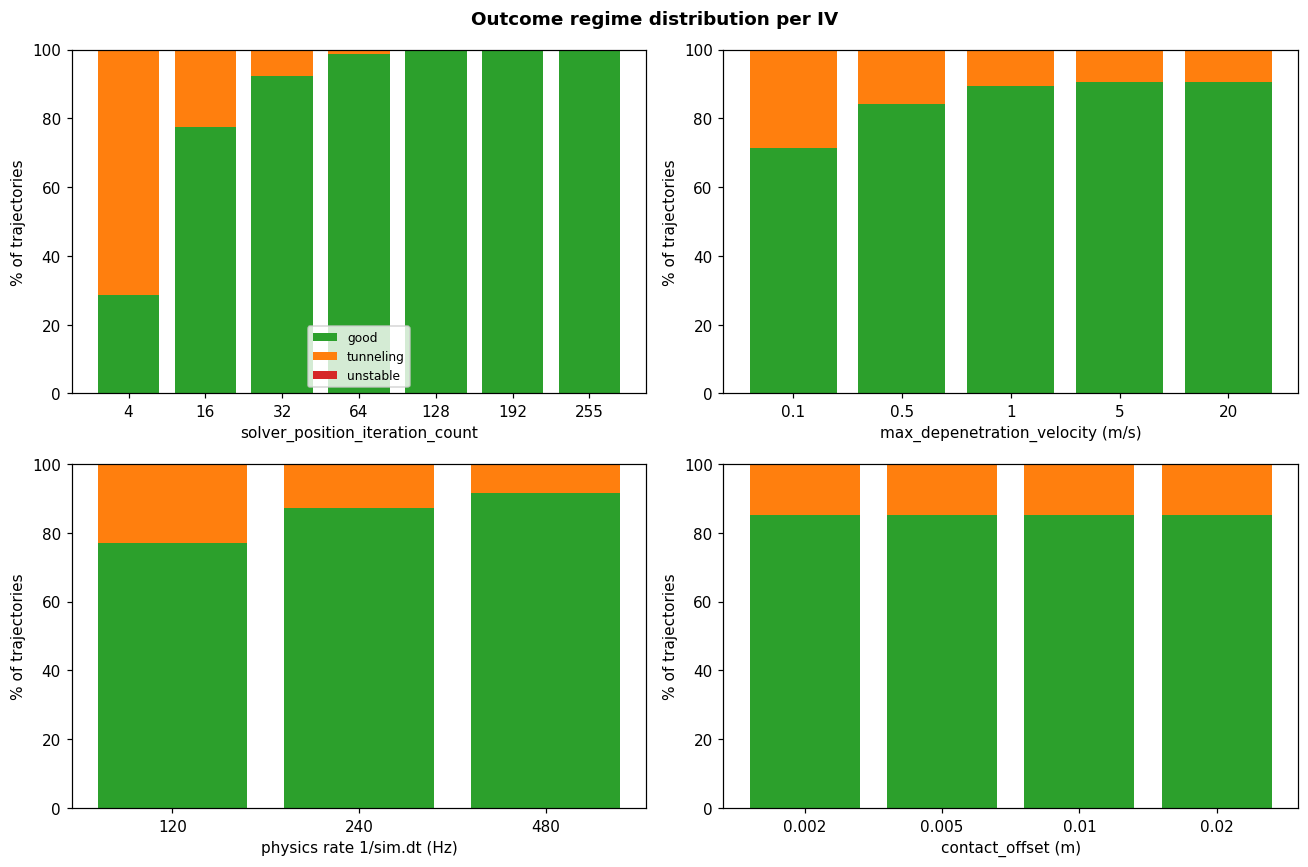

In [51]:
# Overall outcome mix, then a stacked-bar composition vs each IV.
print("Overall outcome mix (%):")
print((df["regime"].value_counts(normalize=True) * 100).round(1).to_string())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, iv in zip(axes.ravel(), IV_COLS):
    xs = _iv_order(iv, df[iv].unique())
    xpos = np.arange(len(xs))
    comp = (pd.crosstab(df[iv], df["regime"], normalize="index")
              .reindex(xs).reindex(columns=REGIMES).fillna(0))
    bottom = np.zeros(len(xs))
    for reg in REGIMES:
        vals = comp[reg].values * 100
        ax.bar(xpos, vals, bottom=bottom, color=REGIME_COLORS[reg], label=reg)
        bottom += vals
    ax.set_xticks(xpos); ax.set_xticklabels(_xticklabels(iv, xs))
    ax.set_xlabel(IV_LABELS[iv]); ax.set_ylabel("% of trajectories"); ax.set_ylim(0, 100)
axes[0, 0].legend(fontsize=8, loc="lower center")
fig.suptitle("Outcome regime distribution per IV", fontweight="bold")
fig.tight_layout()
save_fig(fig, "outcome_regimes")

## Steady-state force error

Settled contact force minus target (signed). Negative = under-shooting the target.

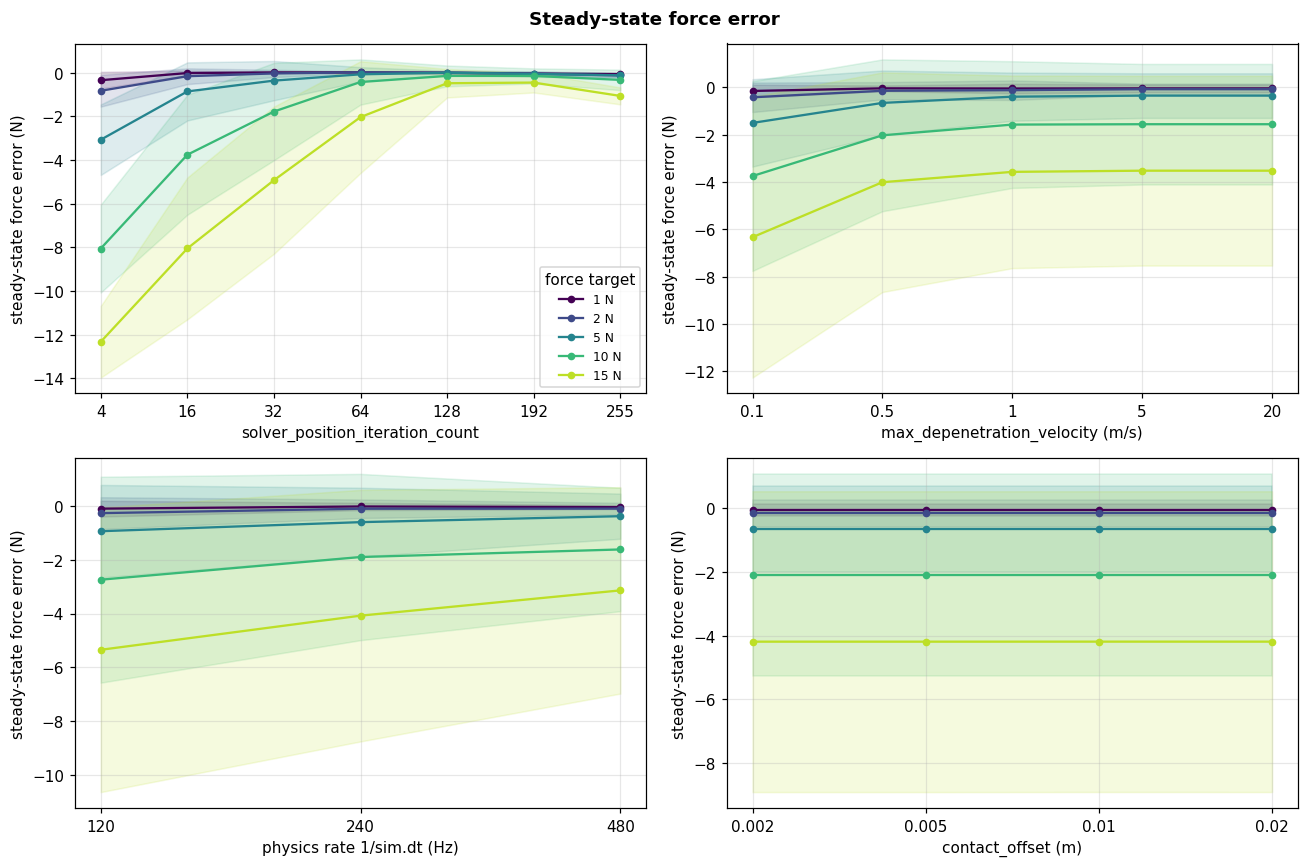

In [52]:
_ = plot_metric_vs_ivs("sse", ylabel="steady-state force error (N)", title="Steady-state force error")

## Residual penetration

How far the cylinder tip sits below the box top surface at steady state. A rigid
contact should keep this sub-mm; large / negative values indicate tunneling /
ejection.

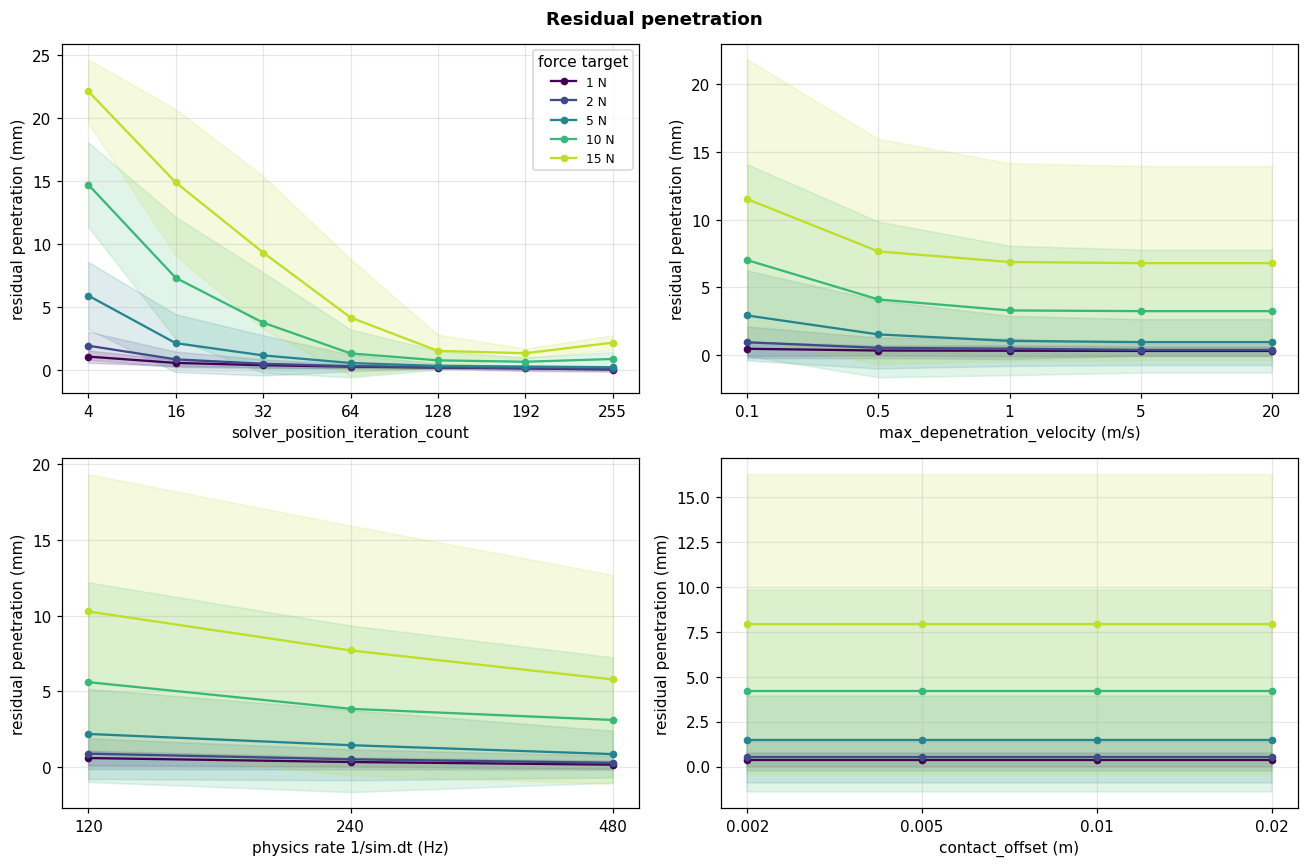

In [53]:
_ = plot_metric_vs_ivs("residual_penetration", scale=1000, ylabel="residual penetration (mm)", title="Residual penetration")

## Force rise time

10→90 % of steady-state force after first contact. With a stiff contact and only
a 0.2 mm approach gap, contact is near-instantaneous, so rise time is often ~0 —
NaN where contact never established.

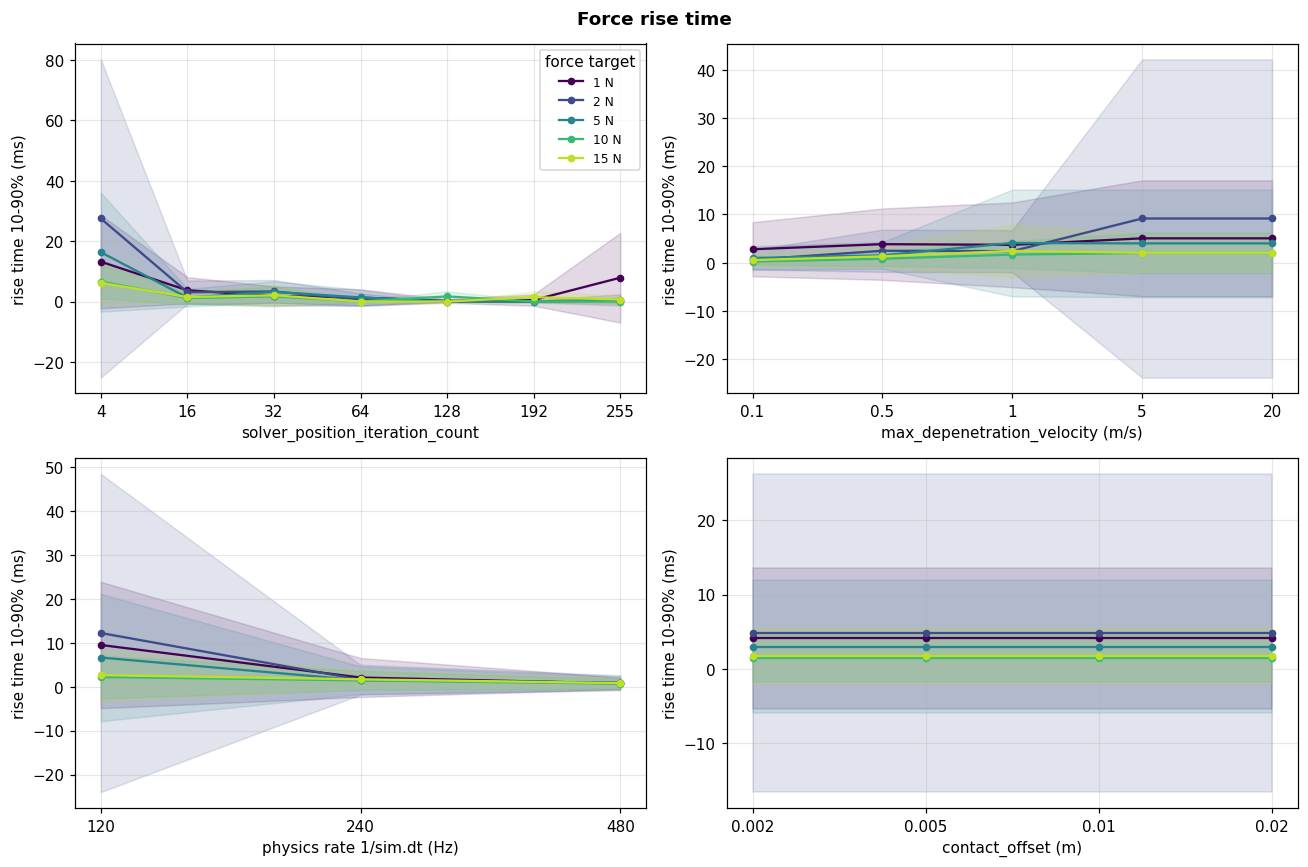

In [54]:
_ = plot_metric_vs_ivs("rise_time", scale=1000, ylabel="rise time 10-90% (ms)", title="Force rise time")

## Overshoot after first contact

Peak force after first contact vs steady state (%). Dominated by the initial
impact slam at low force targets; log-y.

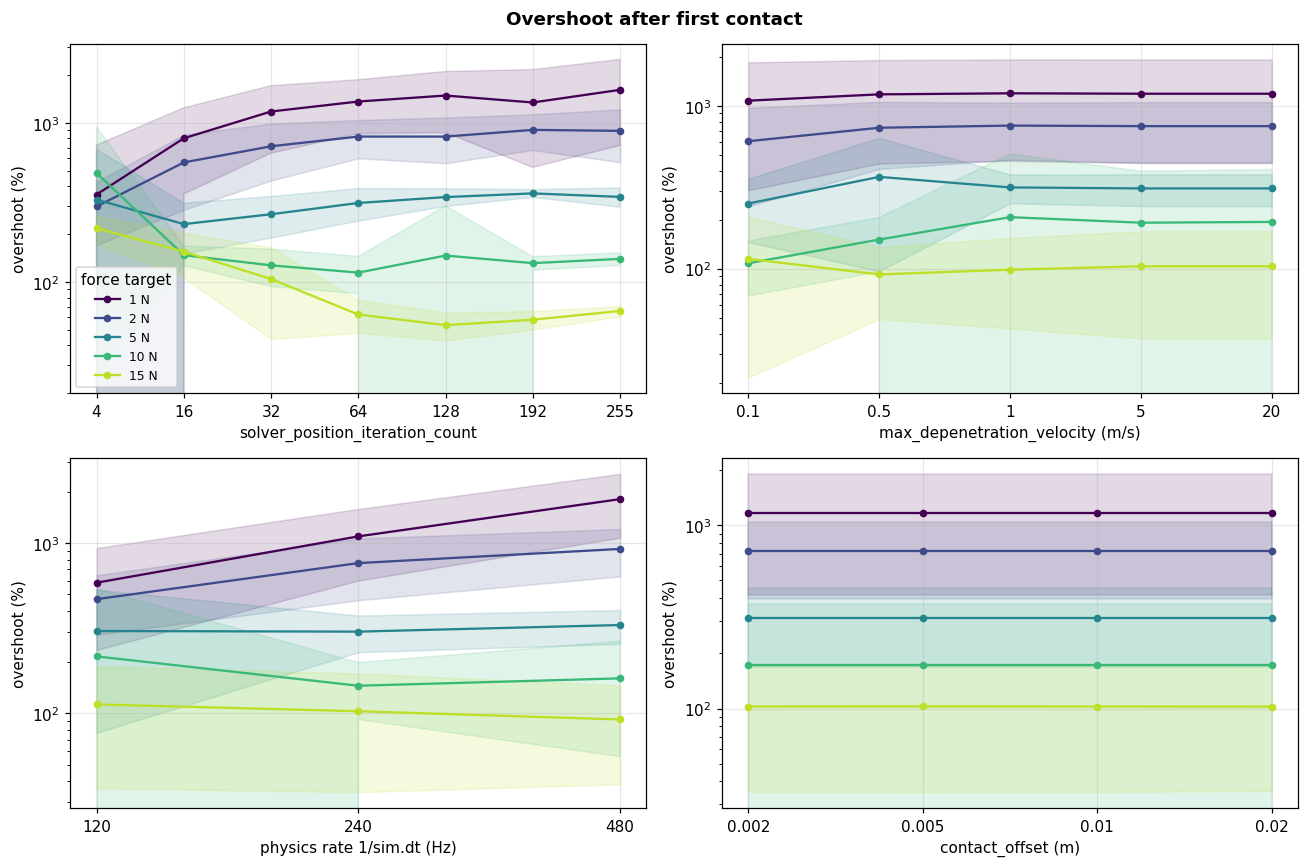

In [55]:
_ = plot_metric_vs_ivs("overshoot", ylabel="overshoot (%)", logy=True, title="Overshoot after first contact")

## Force noise / oscillation amplitude

Std of the contact force over the settled window (`ptp` peak-to-peak is also
stored in the DataFrame).

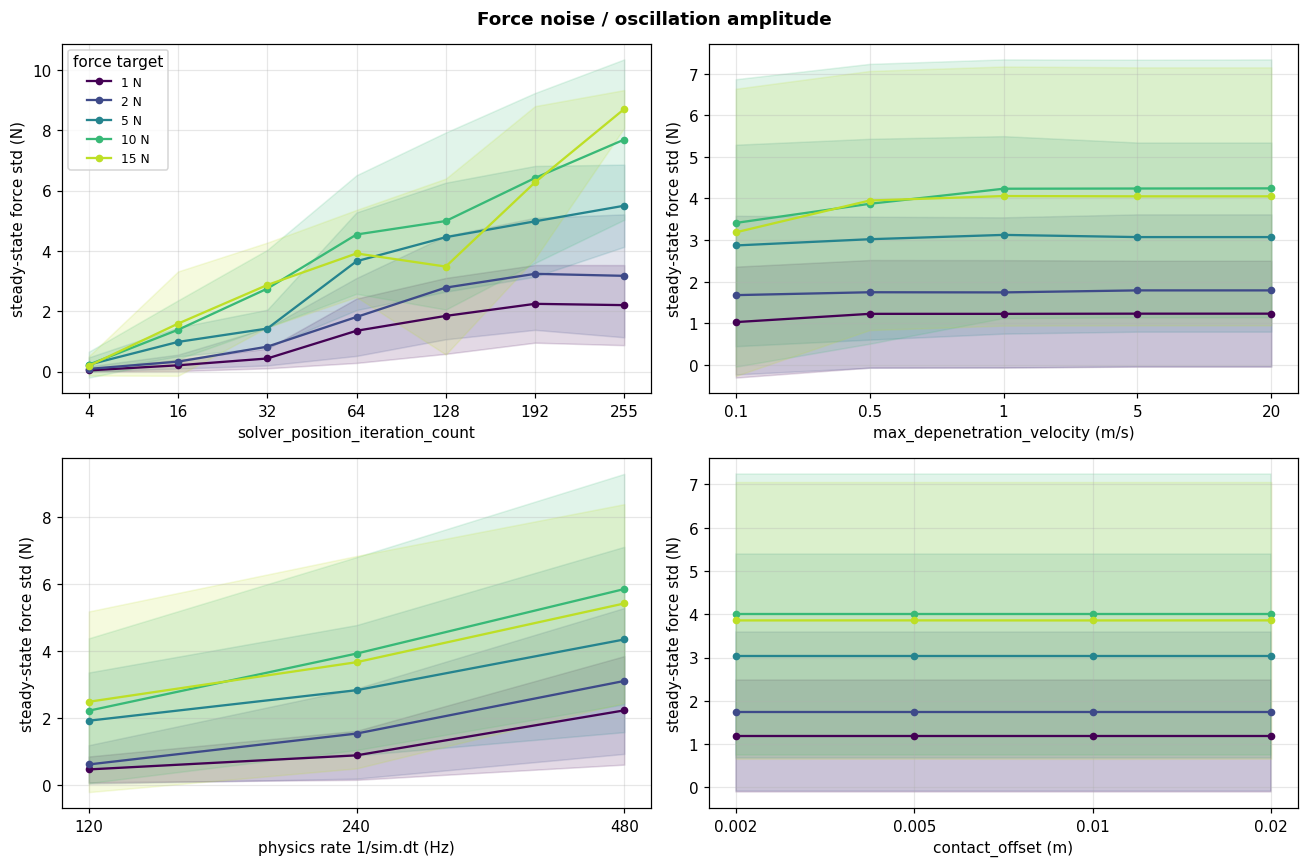

In [56]:
_ = plot_metric_vs_ivs("noise_std", ylabel="steady-state force std (N)", title="Force noise / oscillation amplitude")

## Loading hysteresis (dynamic *F*–δ loop proxy)

Enclosed area of the force–penetration trajectory (the overshoot/settle loop).
See the hysteresis caveat at the top; log-y.

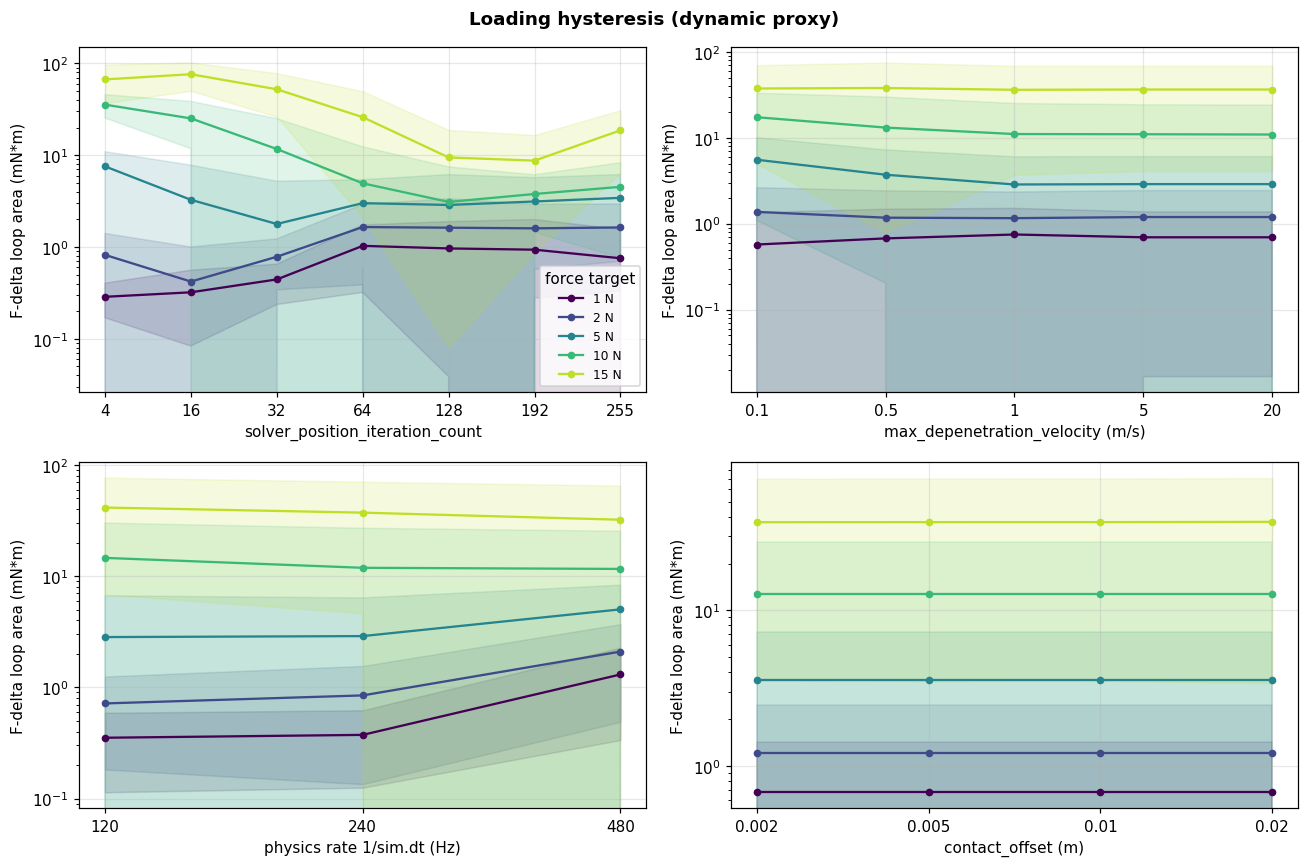

In [57]:
_ = plot_metric_vs_ivs("hysteresis", scale=1000, ylabel="F-delta loop area (mN*m)", logy=True, title="Loading hysteresis (dynamic proxy)")

## Force-estimator cross-check (per-step RMS over the whole trajectory)

Disagreement between the two torque-based EE-force estimates and the contact
sensor, computed as the **RMS of the difference at every step** of the trajectory
(`sqrt(mean((estimate - contact)^2))`) — not just the settled tail. This captures
transient disagreement (impact, settling) that the steady-state view misses, so
even "good" trajectories show a nonzero value from the contact transient. The
signed steady-state columns (`est_err_pinv`, `est_err_dyn`) remain in the
DataFrame if you want those instead.

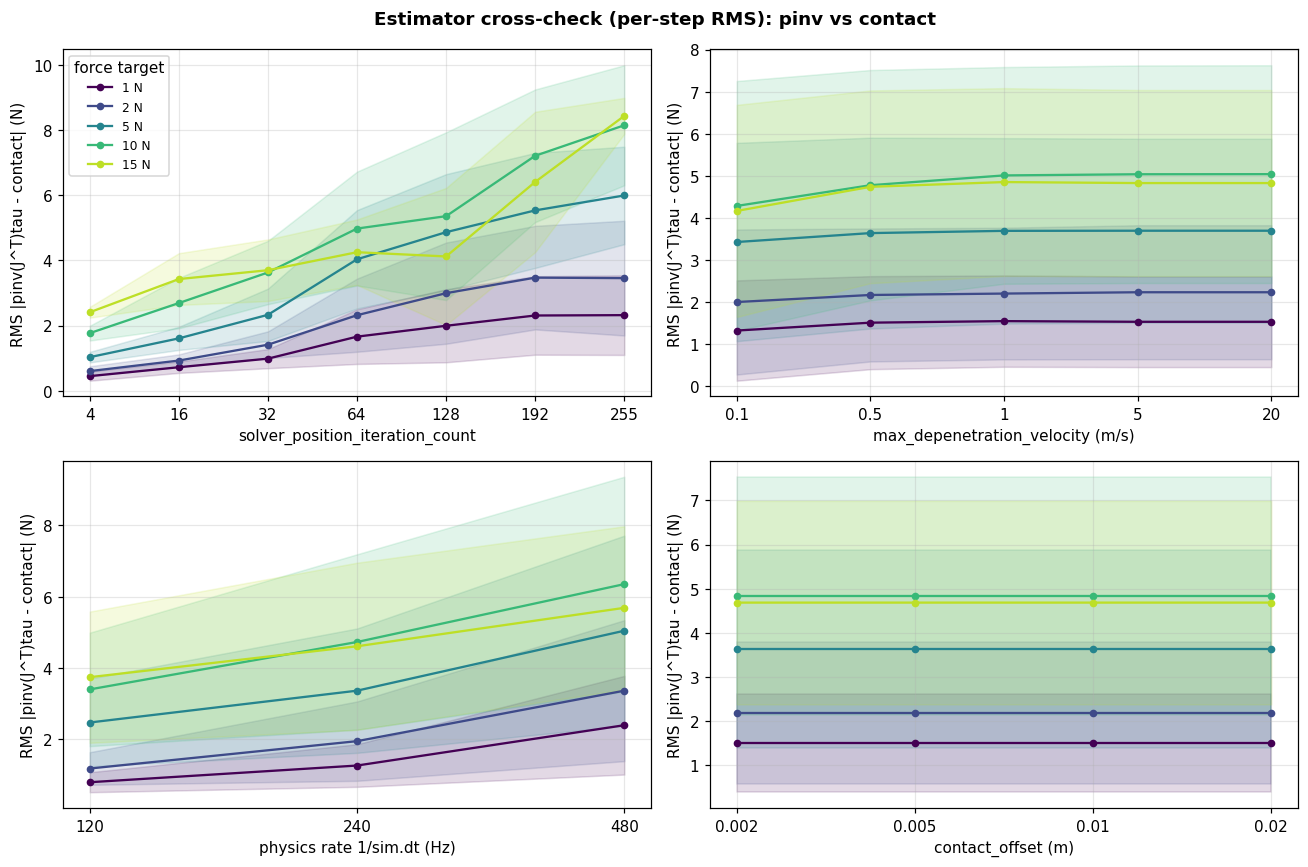

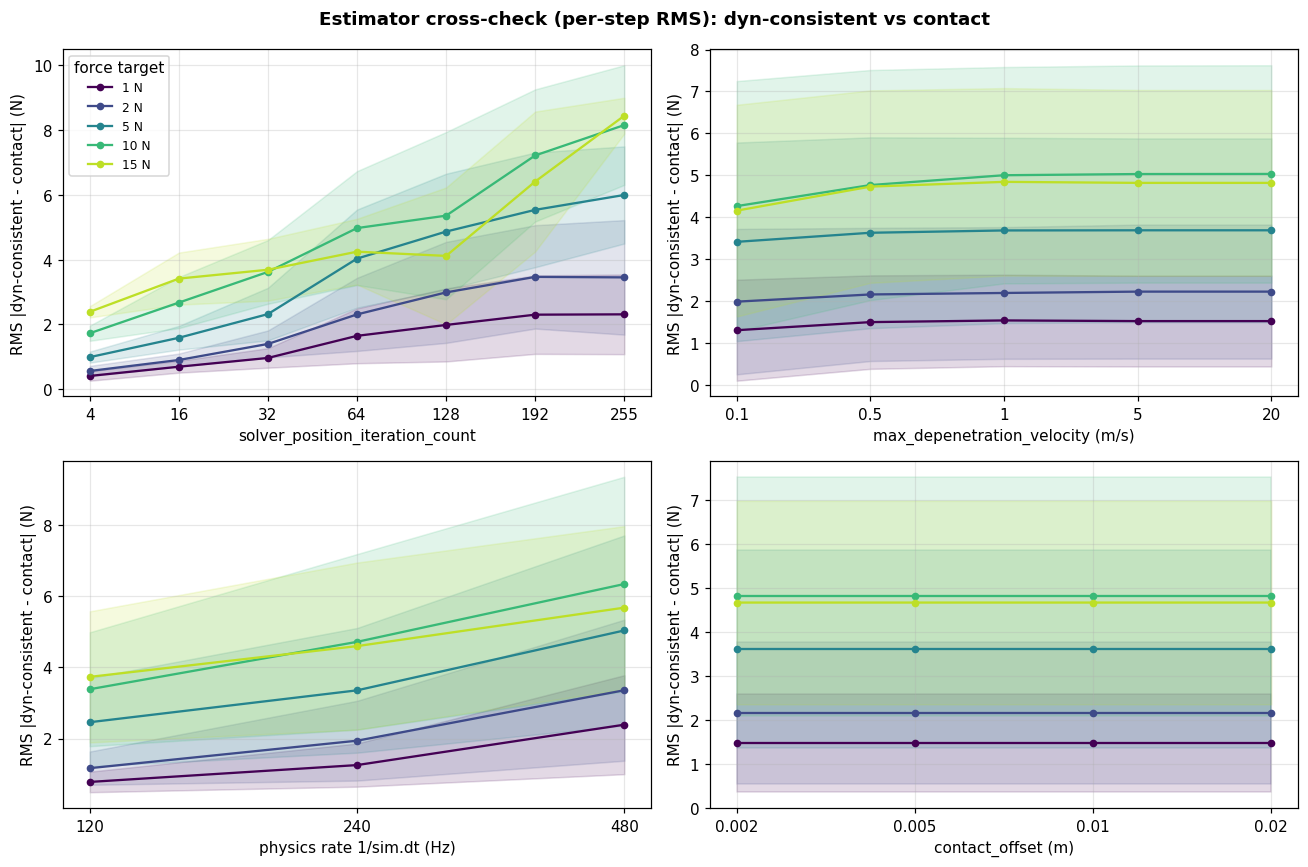

In [58]:
_ = plot_metric_vs_ivs("est_rmse_pinv", ylabel="RMS |pinv(J^T)tau - contact| (N)", title="Estimator cross-check (per-step RMS): pinv vs contact")
_ = plot_metric_vs_ivs("est_rmse_dyn", ylabel="RMS |dyn-consistent - contact| (N)", title="Estimator cross-check (per-step RMS): dyn-consistent vs contact")

## Estimator cross-check (dyn-consistent, per-step RMS) — grouped by outcome regime

Same per-step RMS dyn-consistent disagreement (`RMS |dyn-consistent - contact|`, N)
as above, but with **one line per outcome regime** (good / tunneling / unstable)
instead of per force target. Aggregated (mean ± std) over force targets and the
non-x IVs.

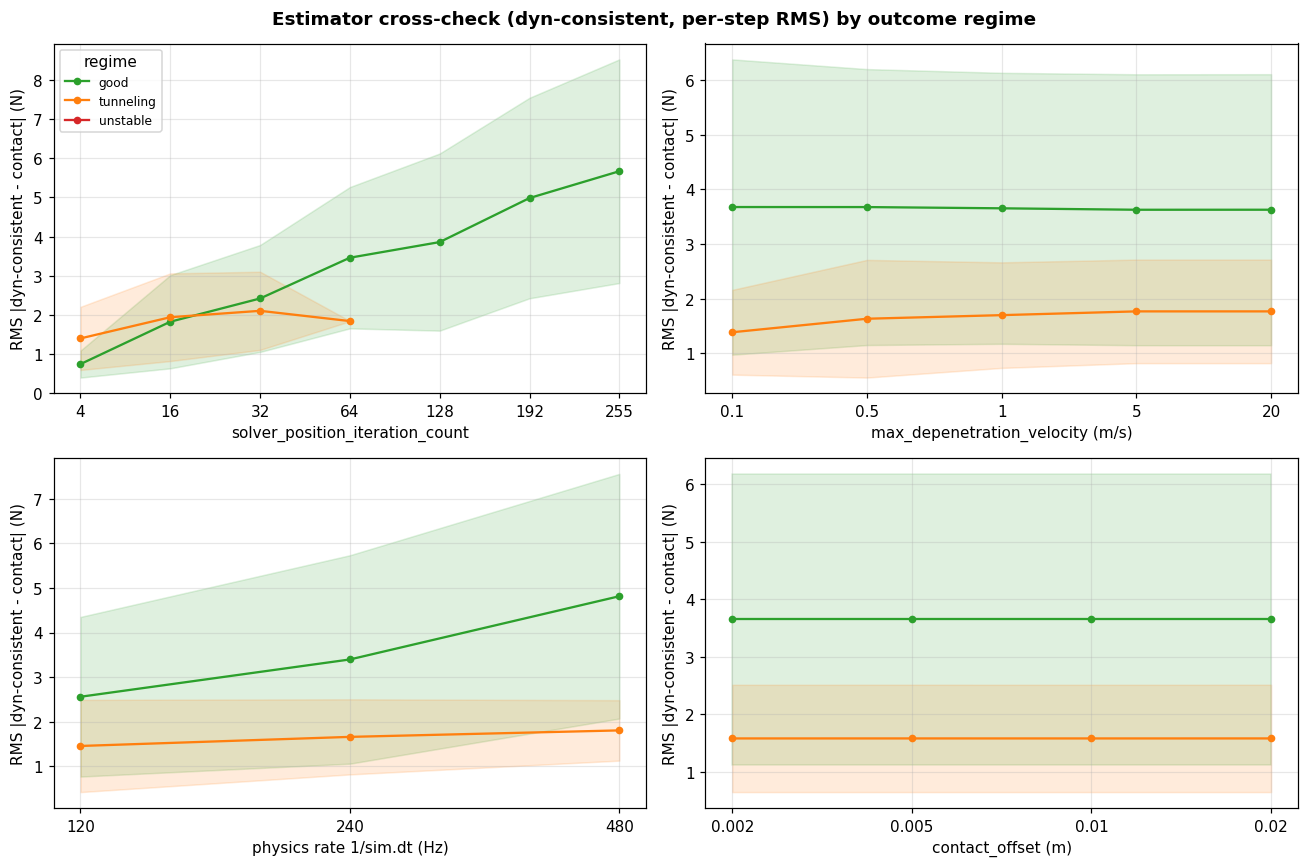

In [59]:
# per-step RMS dyn-consistent error vs each IV, one line per outcome regime.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, iv in zip(axes.ravel(), IV_COLS):
    xs = _iv_order(iv, df[iv].unique())
    xpos = np.arange(len(xs))
    for reg in REGIMES:
        sub = df[df["regime"] == reg]
        g = sub.groupby(iv)["est_rmse_dyn"].agg(["mean", "std"]).reindex(xs)
        mean = g["mean"].values
        std = np.nan_to_num(g["std"].values)
        ax.plot(xpos, mean, "-o", color=REGIME_COLORS[reg], ms=4, label=reg)
        ax.fill_between(xpos, mean - std, mean + std, color=REGIME_COLORS[reg], alpha=0.15)
    ax.set_xticks(xpos); ax.set_xticklabels(_xticklabels(iv, xs))
    ax.set_xlabel(IV_LABELS[iv]); ax.set_ylabel("RMS |dyn-consistent - contact| (N)"); ax.grid(alpha=0.3)
axes[0, 0].legend(title="regime", fontsize=8)
fig.suptitle("Estimator cross-check (dyn-consistent, per-step RMS) by outcome regime", fontweight="bold")
fig.tight_layout()
save_fig(fig, "estimator_crosscheck_by_regime")

## Estimator vs contact sensor — which one is actually noisy?

The per-step RMS above grows with stiffness because of **contact-sensor chatter**,
not estimator error. At high solver iterations the rigid contact resolves as an
alternating full-force / zero-force impulse nearly every substep (a classic
stiff-contact numerical artifact): the contact sensor's settled *mean* stays
correct but its std explodes. The torque-based estimate is inertially low-pass
filtered by the arm, so it stays smooth and sits on the true force — i.e. **the
torque estimate is the more trustworthy of the two here.** Three views below.

**(a)** The per-step RMS `|dyn - contact|` is essentially the contact
sensor's own settled std — points hug the `y = x` line (good regime, colored by
iterations). So that "estimator error" is the contact chatter, not the estimator.

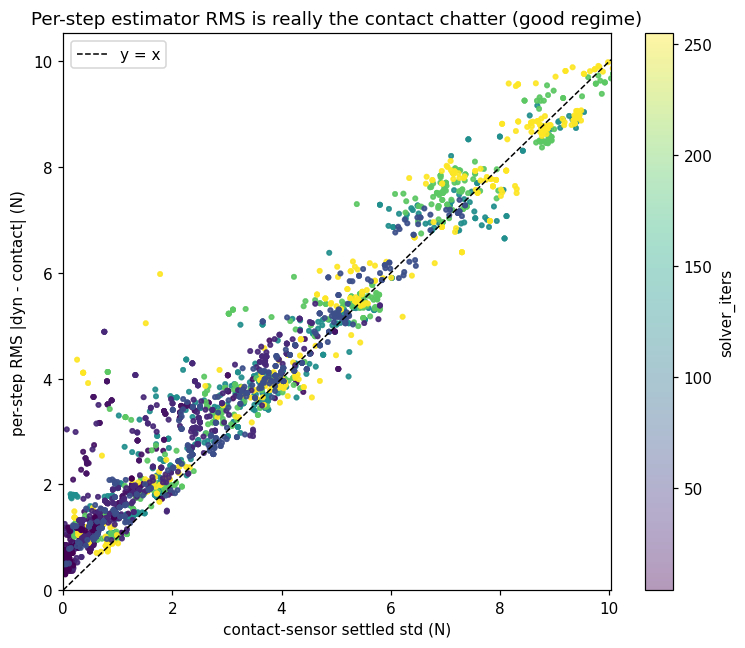

In [60]:
sub = df[df["regime"] == "good"]
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(sub["noise_std"], sub["est_rmse_dyn"], c=sub["solver_iters"],
                cmap="viridis", s=8, alpha=0.4)
hi = float(np.nanpercentile(sub["noise_std"], 99.5))
ax.plot([0, hi], [0, hi], "k--", lw=1, label="y = x")
ax.set_xlim(0, hi); ax.set_ylim(0, None)
ax.set_xlabel("contact-sensor settled std (N)")
ax.set_ylabel("per-step RMS |dyn - contact| (N)")
ax.legend(); fig.colorbar(sc, label="solver_iters")
ax.set_title("Per-step estimator RMS is really the contact chatter (good regime)")
fig.tight_layout()
save_fig(fig, "estimator_vs_contact_scatter")

**(b)** Settled-state std of the **contact sensor** vs the **dyn-consistent
estimate**, per IV, **good regime only**. The contact sensor's std blows up (chatter
grows with stiffness / iterations); the estimate stays near-flat and small.
(Restricted to good contact on purpose — in the unstable regime the arm genuinely
flails, so the estimate is legitimately noisy there and would invert the picture.)

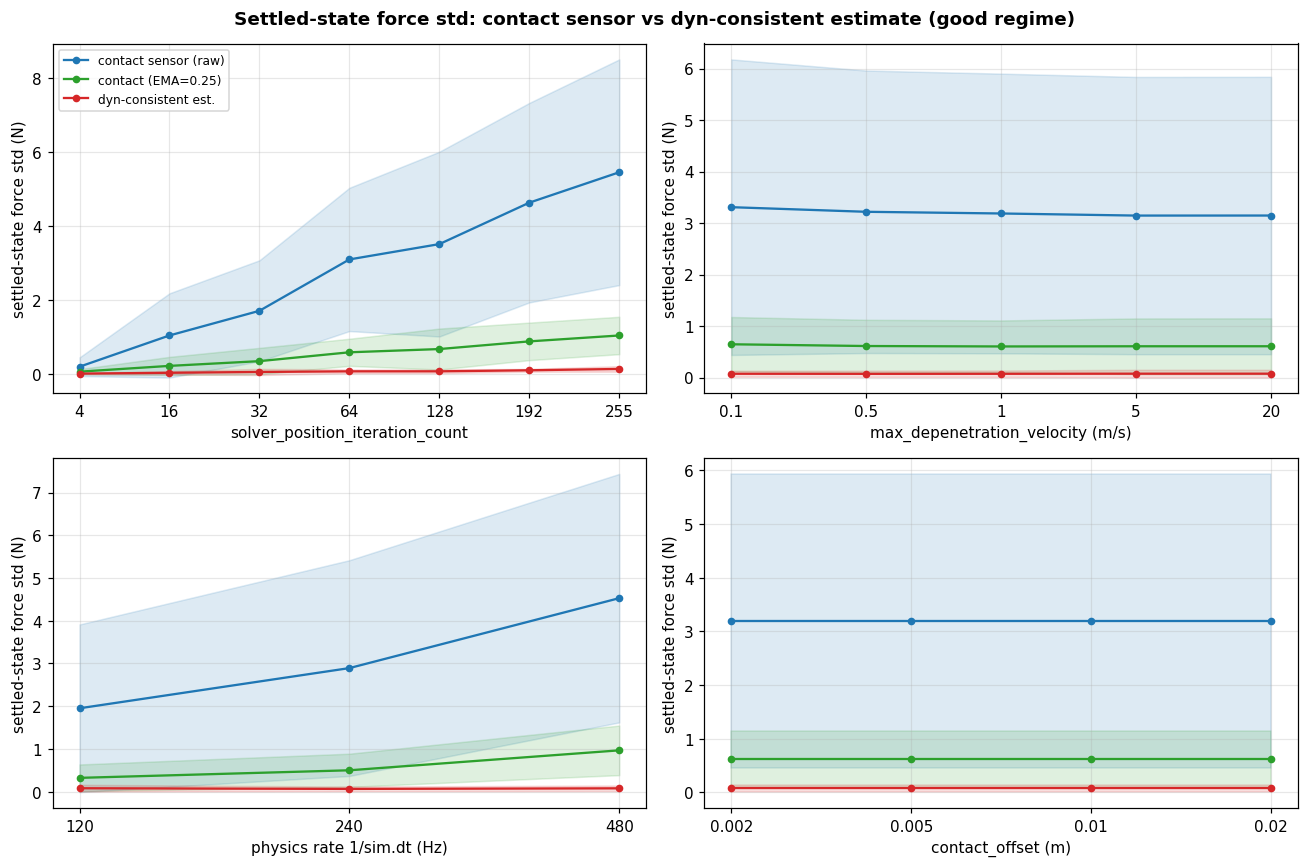

In [61]:
good = df[df["regime"] == "good"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, iv in zip(axes.ravel(), IV_COLS):
    xs = _iv_order(iv, good[iv].unique())
    xpos = np.arange(len(xs))
    for col, name, color in [("noise_std", "contact sensor (raw)", "#1f77b4"),
                             ("filt_noise_std", f"contact (EMA={SIM_EMA_ALPHA})", "#2ca02c"),
                             ("dyn_noise_std", "dyn-consistent est.", "#d62728")]:
        g = good.groupby(iv)[col].agg(["mean", "std"]).reindex(xs)
        m = g["mean"].values; s = np.nan_to_num(g["std"].values)
        ax.plot(xpos, m, "-o", color=color, ms=4, label=name)
        ax.fill_between(xpos, m - s, m + s, color=color, alpha=0.15)
    ax.set_xticks(xpos); ax.set_xticklabels(_xticklabels(iv, xs))
    ax.set_xlabel(IV_LABELS[iv]); ax.set_ylabel("settled-state force std (N)"); ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Settled-state force std: contact sensor vs dyn-consistent estimate (good regime)", fontweight="bold")
fig.tight_layout()
save_fig(fig, "settled_std_contact_vs_dyn")

**(c)** Force-vs-time overlay for one trajectory at low vs high solver
iterations (edit the args to inspect any condition). The contact sensor (blue)
chatters between ~2x the force and 0; the dyn-consistent estimate (red) is a clean
line on the target. Loaded straight from the `.npz` on disk, so global filters
don't affect it.

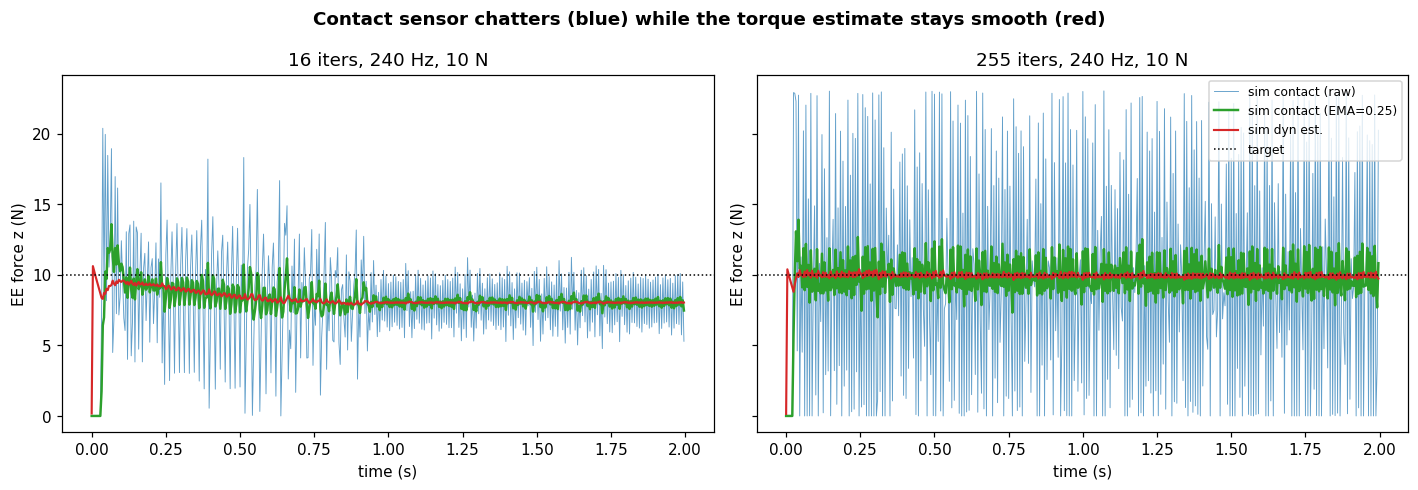

In [62]:
def _cond_file(iters, max_depen, dt_denom, contact_offset):
    fmt = lambda x: str(x).replace(".", "-")
    return os.path.join(DATA_DIR, f"{iters}_{fmt(max_depen)}_{dt_denom}_{fmt(contact_offset)}.npz")


def plot_force_timeseries(ax, iters, max_depen, dt_denom, contact_offset, force_target, env=0,
                          overlay_real=False):
    d = np.load(_cond_file(iters, max_depen, dt_denom, contact_offset), allow_pickle=True)
    fi = int(np.argmin(np.abs(d["force_targets"] - force_target)))
    t = d["t"][fi]; t = t - t[0]          # zero per force level (sim t is absolute sweep time)
    ax.plot(t, d["contact_force_ee"][fi, :, env, 2], color="#1f77b4", lw=0.6, alpha=0.7, label="sim contact (raw)")
    ax.plot(t, _ema(d["contact_force_ee"][fi, :, env, 2], SIM_EMA_ALPHA), color="#2ca02c", lw=1.6, label=f"sim contact (EMA={SIM_EMA_ALPHA})")
    ax.plot(t, d["est_force_ee_dynconsistent"][fi, :, env, 2], color="#d62728", lw=1.4, label="sim dyn est.")
    ax.axhline(force_target, color="k", ls=":", lw=1, label="target")
    # overlay real (mean over reps) at the matching force level, on its own 0..2 s axis
    if overlay_real and float(force_target) in REAL_TRACES:
        rt = REAL_TRACES[float(force_target)]
        ax.plot(rt["t"], rt["contact"].mean(0), color="#08306b", lw=2, ls="--", label="real O_F_ext")
    ax.set_xlabel("time (s)"); ax.set_ylabel("EE force z (N)")
    ax.set_title(f"{iters} iters, {dt_denom} Hz, {force_target:g} N")

# Same condition at low vs high solver iterations (edit these freely).
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
plot_force_timeseries(axes[0], 16, 5.0, 240, 0.005, 10.0)
plot_force_timeseries(axes[1], 255, 5.0, 240, 0.005, 10.0)
axes[1].legend(fontsize=8, loc="upper right")
fig.suptitle("Contact sensor chatters (blue) while the torque estimate stays smooth (red)", fontweight="bold")
fig.tight_layout()
save_fig(fig, "force_timeseries_overlay")

**(d)** The same overlay across the solver-iteration levels (192 dropped for an
even 6 in a 3-column grid). Set `force_target` and `rate_hz` at the top of the cell
to inspect any other condition — the contact-chatter-vs-iterations progression.

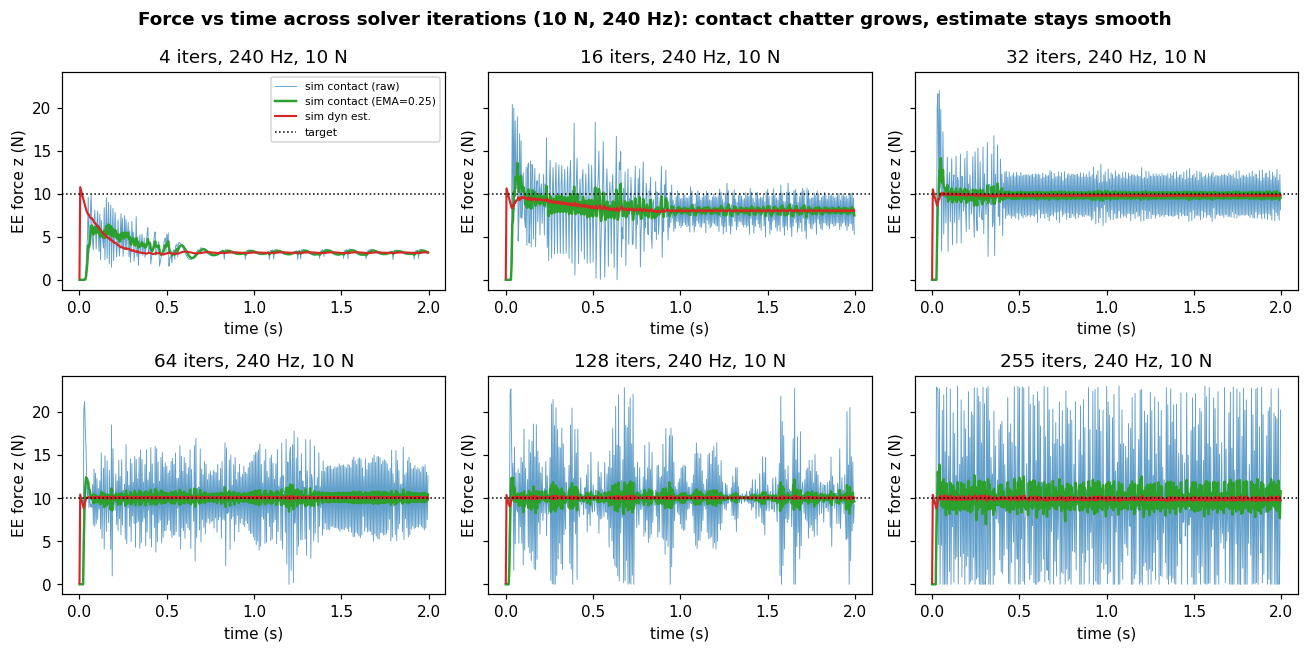

In [63]:
# --- edit these two to change the condition shown (local to this cell) ---
force_target = 10.0     # N: one of 1, 2, 5, 10, 15
rate_hz = 240           # physics rate = 1/sim.dt (Hz): one of 60, 120, 240, 480
# other conditions held fixed:
max_depen, contact_offset = 5.0, 0.005

iter_levels = [it for it in sorted(df_full["solver_iters"].unique()) if it != 192]  # drop 192 -> even 6
ncol = 3
nrow = int(np.ceil(len(iter_levels) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.0 * ncol, 3.0 * nrow), sharey=True)
axf = np.atleast_1d(axes).ravel()
for ax, it in zip(axf, iter_levels):
    plot_force_timeseries(ax, it, max_depen, rate_hz, contact_offset, force_target)
for ax in axf[len(iter_levels):]:
    ax.axis("off")
axf[0].legend(fontsize=7, loc="upper right")
fig.suptitle(f"Force vs time across solver iterations ({force_target:g} N, {rate_hz} Hz): "
             f"contact chatter grows, estimate stays smooth", fontweight="bold")
fig.tight_layout()
save_fig(fig, "force_timeseries_across_iters")

# Sim vs real (FR3)

All comparisons below use **only the force levels present in the real data**
(`REAL_FORCES`), with the sim restricted to the **good** regime (contact resolved)
so tunneling/unstable corners don't distort it. Real values are the mean over the
10 reps. (Recall the real force is ~4x the command from the `J^T.Lambda` mapping,
and the real est is gravity-hacked — see the real-data section.)

## Sim − real difference vs sim parameters

**One figure per force target** (then a force-weighted average across all forces).
Each figure is the usual 2x2-IV grid, with **three lines** — all minus the real
`O_F_ext`:
- **sim contact (raw)** — the unfiltered PhysX contact sensor,
- **sim contact (EMA=`SIM_EMA_ALPHA`)** — that signal EMA-smoothed with the FORGE
  `ft_smoothing_factor` (default 0.25), i.e. what a trained policy sees,
- **sim dyn-consistent** — the torque-based estimate.

Dashed 0 line = exact agreement. (Raw and EMA-filtered nearly overlap here because
the EMA preserves the *mean*; they differ in noise, shown in the std plots.)

The final figure averages the difference over all forces, **weighting each force
condition by its target magnitude** (so higher forces dominate).

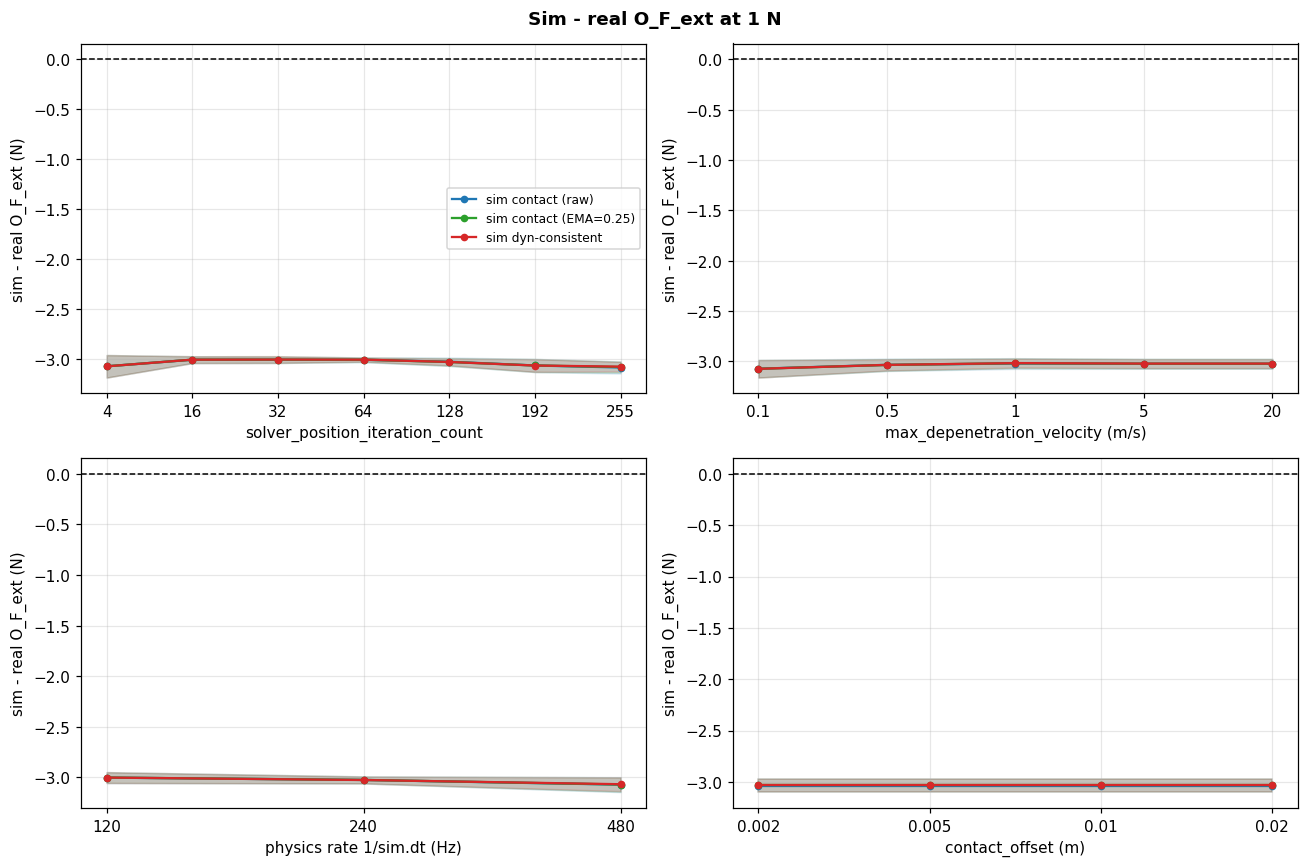

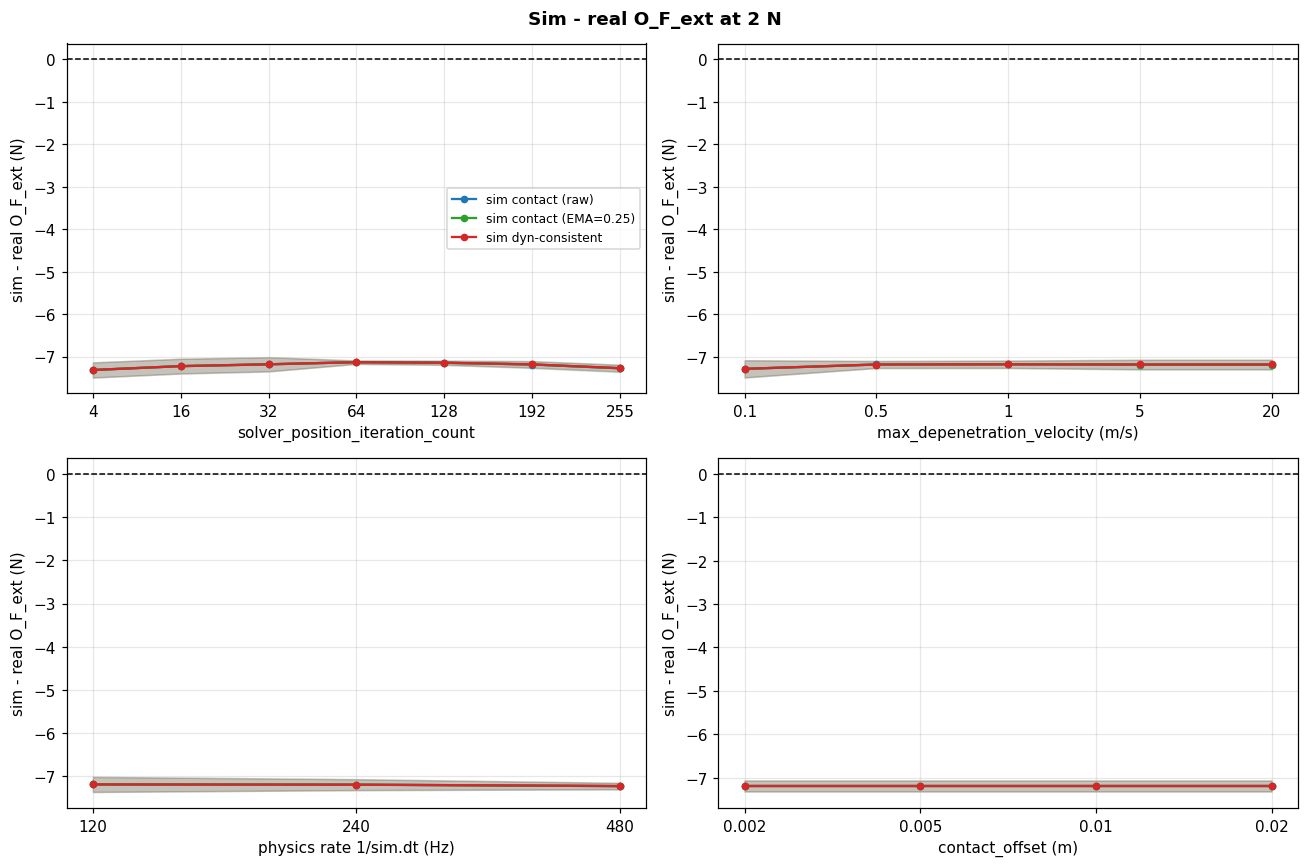

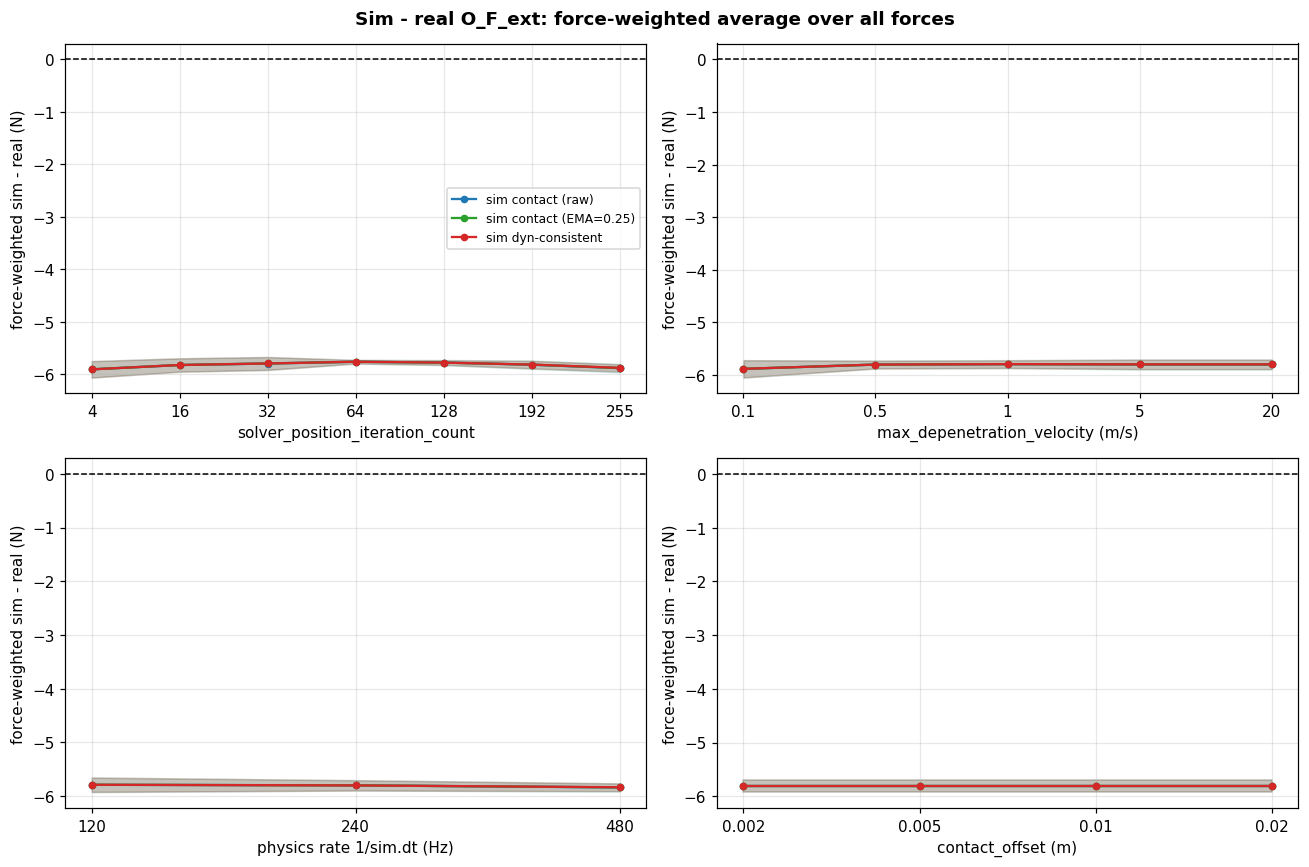

In [64]:
SIM_CHANNELS = [("contact_ss", "sim contact (raw)", "#1f77b4"),
                ("filt_contact_ss", f"sim contact (EMA={SIM_EMA_ALPHA})", "#2ca02c"),
                ("dyn_ss", "sim dyn-consistent", "#d62728")]


def plot_diff_by_force(force):
    data = df[(df["regime"] == "good") & (df[FORCE_COL] == force)]
    real_val = float(REAL[force]["contact"].mean())
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, iv in zip(axes.ravel(), IV_COLS):
        xs = _iv_order(iv, data[iv].unique()); xpos = np.arange(len(xs))
        for col, name, color in SIM_CHANNELS:
            g = data.groupby(iv)[col].agg(["mean", "std"]).reindex(xs)
            m = g["mean"].values - real_val; s = np.nan_to_num(g["std"].values)
            ax.plot(xpos, m, "-o", color=color, ms=4, label=name)
            ax.fill_between(xpos, m - s, m + s, color=color, alpha=0.15)
        ax.axhline(0, color="k", lw=1, ls="--")
        ax.set_xticks(xpos); ax.set_xticklabels(_xticklabels(iv, xs))
        ax.set_xlabel(IV_LABELS[iv]); ax.set_ylabel("sim - real O_F_ext (N)"); ax.grid(alpha=0.3)
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(f"Sim - real O_F_ext at {force:g} N", fontweight="bold")
    fig.tight_layout(); save_fig(fig, f"sim_minus_real_{force:g}N")


def plot_diff_weighted():
    data = df[(df["regime"] == "good") & (df[FORCE_COL].isin(REAL_FORCES))]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, iv in zip(axes.ravel(), IV_COLS):
        xs = _iv_order(iv, data[iv].unique()); xpos = np.arange(len(xs))
        for col, name, color in SIM_CHANNELS:
            num = np.zeros(len(xs)); bnum = np.zeros(len(xs)); wsum = np.zeros(len(xs))
            for f in REAL_FORCES:
                g = data[data[FORCE_COL] == f].groupby(iv)[col].agg(["mean", "std"]).reindex(xs)
                diff = g["mean"].values - float(REAL[f]["contact"].mean())
                ok = ~np.isnan(diff)
                num += f * np.where(ok, diff, 0.0)
                bnum += f * np.where(ok, np.nan_to_num(g["std"].values), 0.0)
                wsum += f * ok
            m = np.where(wsum > 0, num / np.where(wsum > 0, wsum, 1), np.nan)
            s = np.where(wsum > 0, bnum / np.where(wsum > 0, wsum, 1), np.nan)
            ax.plot(xpos, m, "-o", color=color, ms=4, label=name)
            ax.fill_between(xpos, m - s, m + s, color=color, alpha=0.15)
        ax.axhline(0, color="k", lw=1, ls="--")
        ax.set_xticks(xpos); ax.set_xticklabels(_xticklabels(iv, xs))
        ax.set_xlabel(IV_LABELS[iv]); ax.set_ylabel("force-weighted sim - real (N)"); ax.grid(alpha=0.3)
    axes[0, 0].legend(fontsize=8)
    fig.suptitle("Sim - real O_F_ext: force-weighted average over all forces", fontweight="bold")
    fig.tight_layout(); save_fig(fig, "sim_minus_real_weighted")


if REAL_FORCES:
    for f in sorted(REAL_FORCES):
        plot_diff_by_force(f)
    plot_diff_weighted()
else:
    print("no real data loaded")

## Force std: sim vs real (matched forces)

Settled-state std of the sim contact sensor and dyn estimate (good regime, matched
forces), with the real `O_F_ext` **within-hold** std as a reference line — the
temporal std over one 0.5 s hold. It's tiny (~0.02 N) because `O_F_ext` is
EMA-filtered (0.08 @ 1 kHz), so the signal barely moves during a hold; this is the
apples-to-apples analog of the sim's within-trajectory std.

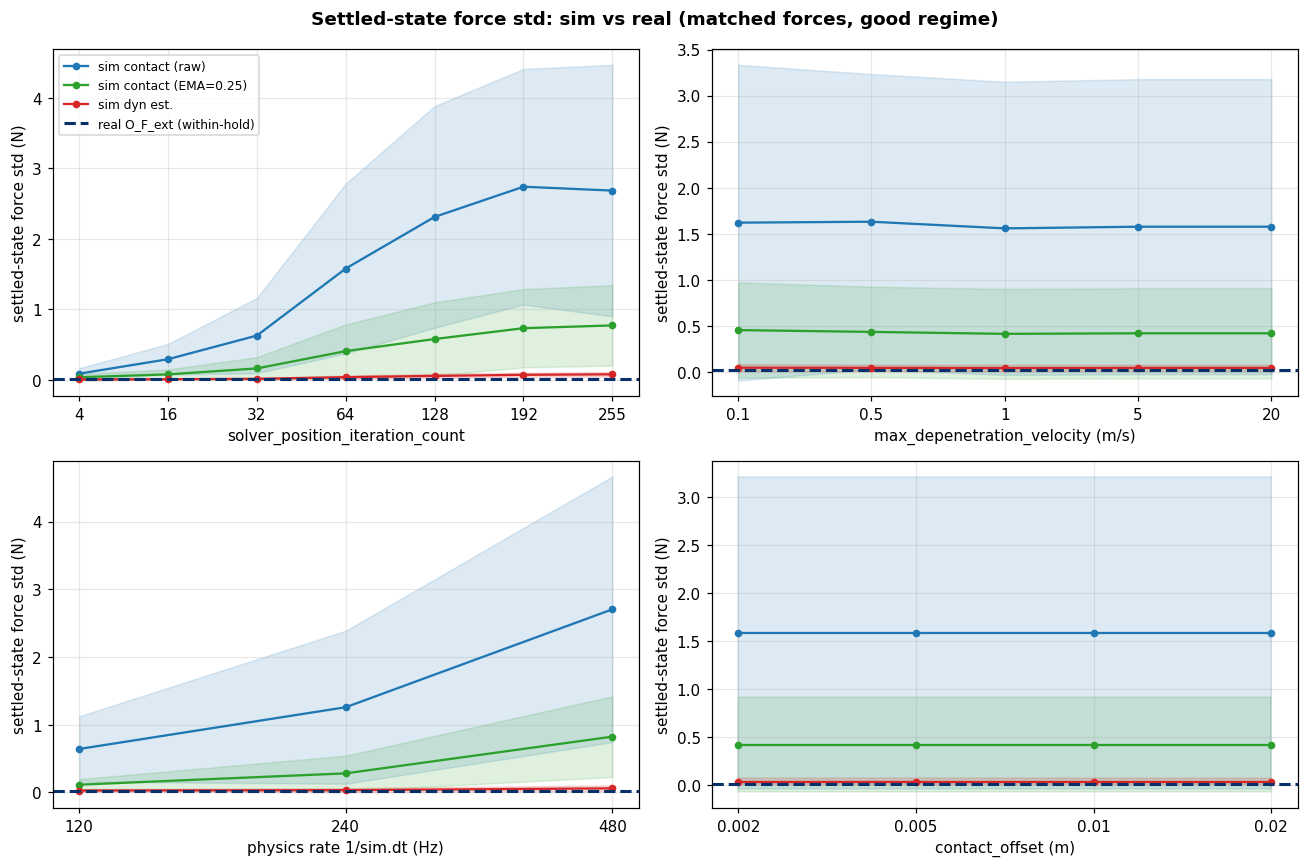

In [65]:
if REAL_FORCES:
    data = df[(df["regime"] == "good") & (df[FORCE_COL].isin(REAL_FORCES))]
    real_within = float(np.mean([REAL[f]["contact_std"].mean() for f in REAL_FORCES]))  # temporal, within a hold
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, iv in zip(axes.ravel(), IV_COLS):
        xs = _iv_order(iv, data[iv].unique()); xpos = np.arange(len(xs))
        for col, name, color in [("noise_std", "sim contact (raw)", "#1f77b4"),
                                 ("filt_noise_std", f"sim contact (EMA={SIM_EMA_ALPHA})", "#2ca02c"),
                                 ("dyn_noise_std", "sim dyn est.", "#d62728")]:
            g = data.groupby(iv)[col].agg(["mean", "std"]).reindex(xs)
            m = g["mean"].values; s = np.nan_to_num(g["std"].values)
            ax.plot(xpos, m, "-o", color=color, ms=4, label=name)
            ax.fill_between(xpos, m - s, m + s, color=color, alpha=0.15)
        ax.axhline(real_within, color="#08306b", lw=2, ls="--", label="real O_F_ext (within-hold)")
        ax.set_xticks(xpos); ax.set_xticklabels(_xticklabels(iv, xs))
        ax.set_xlabel(IV_LABELS[iv]); ax.set_ylabel("settled-state force std (N)"); ax.grid(alpha=0.3)
    axes[0, 0].legend(fontsize=8)
    fig.suptitle("Settled-state force std: sim vs real (matched forces, good regime)", fontweight="bold")
    fig.tight_layout(); save_fig(fig, "std_sim_vs_real")
else:
    print("no real data loaded")

## Force vs time: sim with real overlaid (matched forces)

Sim example (solid: sim contact blue, sim dyn red) with the real data overlaid
(dashed: real O_F_ext, mean over reps) at each real force
level. Sim condition editable at the top of the cell.

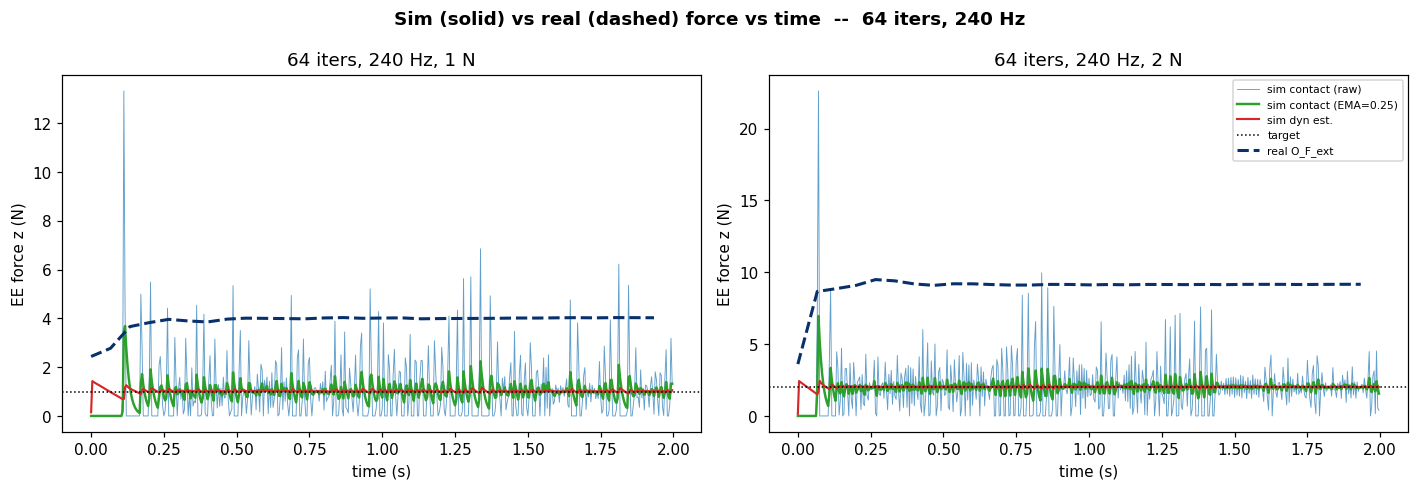

In [66]:
if REAL_FORCES:
    iters, max_depen, dt_denom, contact_offset = 64, 5.0, 240, 0.005   # sim condition
    fs = sorted(REAL_FORCES)
    fig, axes = plt.subplots(1, len(fs), figsize=(6.5 * len(fs), 4.5), squeeze=False)
    for ax, ft in zip(axes[0], fs):
        plot_force_timeseries(ax, iters, max_depen, dt_denom, contact_offset, ft, overlay_real=True)
    axes[0, -1].legend(fontsize=7, loc="upper right")
    fig.suptitle(f"Sim (solid) vs real (dashed) force vs time  --  {iters} iters, {dt_denom} Hz",
                 fontweight="bold")
    fig.tight_layout(); save_fig(fig, "force_timeseries_sim_vs_real")
else:
    print("no real data loaded")